STAlign test


In [1]:
from wsireg.wsireg2d import WsiReg2D
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
import os
import shutil

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
# files
sample = "lungTMA6"
output_dir = "results/" + sample + "/"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)
else:
    shutil.rmtree(output_dir)
    os.mkdir(output_dir)
valid_target_landmarks = "../../../benchmarks/landmarks/LungTMA/" + sample + "/HE_landmarks_corrected.csv"
valid_source_landmarks = "../../../benchmarks/landmarks/LungTMA/" + sample + "/Xenium_landmarks_corrected.csv"
query_img = Image.open('../../../../../analysis/ImageAlignmentBenchmark/data/LungTMA/Xenium/lungTMA_Assay6.tif')
ref_img = Image.open('../../../../../analysis/ImageAlignmentBenchmark/data/LungTMA/HE/lungTMA_6.jpg')


Image size (91126116 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.


In [3]:
# initialize registration graph
reg_graph = WsiReg2D("my_reg_project", output_dir= output_dir)

In [4]:
# add registration images (modalities)
rotated = query_img.rotate(270, expand=True)
query_img_size = rotated.size
rotated.save(output_dir + "input.tiff")
reg_graph.add_modality(
    "modality_fluo",
    output_dir + "input.tiff",
    image_res=1,
    preprocessing={
        "image_type": "BF",
        "as_uint8": True,
        "invert_intensity": True,
    },
)

In [5]:
original_size = ref_img.size
rotated_ref_img = ref_img.resize(query_img_size)
rotated_ref_img.save(output_dir + 'output.tiff')
reg_graph.add_modality(
    "modality_brightfield",
    output_dir + "output.tiff",
    image_res=1,
    preprocessing={
        "image_type": "FL", 
        "as_uint8": True,
        "invert_intensity": False,
    }
)

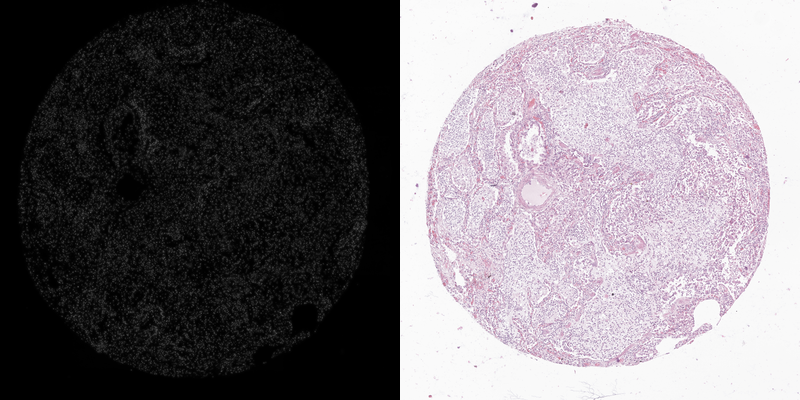

In [6]:
img1 = Image.open(output_dir + 'input.tiff')
img2 = Image.open(output_dir + 'output.tiff')
img1 = img1.resize((400,400), Image.LANCZOS)
img2 = img2.resize((400,400), Image.LANCZOS)
img1 = img1.convert("RGB")
img2 = img2.convert("RGB")
new_img = Image.new("RGB", (800, 400))
new_img.paste(img1, (0, 0))
new_img.paste(img2, (400, 0))
display(new_img)

   Unnamed: 0  KeyPoint            x            y
0           1         1  7415.225732  1688.572066
1           2         2  6560.027500  1231.900000
2           3         3  6027.429388  1019.747586
3           4         4  5377.056152   932.942489
4           5         5  4256.549142   990.460075
[[7415.22573193 7857.42793365]
 [6560.0275     8314.1       ]
 [6027.42938815 8526.25241387]
 [5377.05615153 8613.05751115]
 [4256.54914179 8555.53992469]]
   Unnamed: 0  KeyPoint            x           y
0           1         1  4909.925672  947.011077
1           2         2  4330.619399  635.223732
2           3         3  3968.265118  493.401958
3           4         4  3528.110068  433.064239
4           5         5  2766.129287  472.276493
[[4909.9256718  5010.98892279]
 [4330.619399   5322.77626833]
 [3968.26511795 5464.59804195]
 [3528.1100681  5524.93576076]
 [2766.12928672 5485.72350744]]


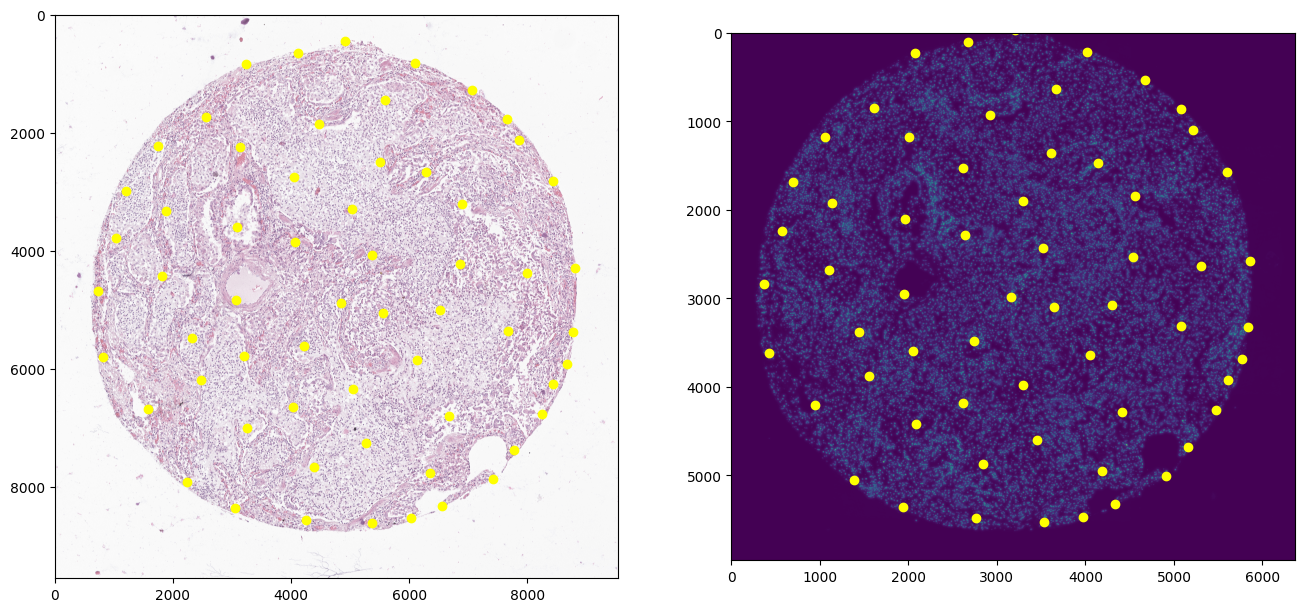

In [7]:
# get landmarks
he_landmarks_df = pd.read_csv(valid_target_landmarks)
print(he_landmarks_df.head())
he_landmarks = np.array(he_landmarks_df[['x', 'y']])
he_landmarks[:,1] =  original_size[1] - he_landmarks[:,1]
print(he_landmarks[:5])
Xenium_landmarks_df = pd.read_csv(valid_source_landmarks)
print(Xenium_landmarks_df.head())
Xenium_landmarks = np.array(Xenium_landmarks_df[['x', 'y']])
Xenium_landmarks[:,1] =  rotated.size[1] - Xenium_landmarks[:,1]
print(Xenium_landmarks[:5])

# visualize landmarks
fig,ax = plt.subplots(1,2)
fig.set_size_inches(16, 8)
img = ref_img
ax[0].scatter(he_landmarks[:,0], he_landmarks[:,1], alpha=1, c="yellow")
ax[0].imshow(img)
img = query_img
rotated = img.rotate(270, expand=True)
ax[1].scatter(Xenium_landmarks[:,0],Xenium_landmarks[:,1],alpha=1, c = "yellow")
ax[1].imshow(rotated)

# add shapes to modality
reg_graph.add_shape_set("modality_fluo", "Xenium_landmarks", {"array": Xenium_landmarks, "shape_type": "Point", "shape_name" : "Xenium_landmarks"}, 1)

In [8]:
reg_graph.add_reg_path(
    "modality_fluo",
    "modality_brightfield",
    thru_modality=None,
    reg_params=["affine"],
)

In [10]:
reg_graph.register_images()
reg_graph.save_transformations()
reg_graph.transform_images(file_writer="ome.tiff")
reg_graph.transform_shapes()

cannot perform maximum intensity project on single channel image
Writing preprocessed image for modality_brightfield
Finished writing preprocessed image for modality_brightfield
using default compression
saving to results/lungTMA6/my_reg_project-modality_fluo_to_modality_brightfield_registered.ome.tiff
transforming : 0
transformed : 0
saving
 writing channel 0 - shape: (5958, 6366)
pyramid index 1 : channel 0 shape: (2979, 3183)
pyramid index 2 : channel 0 shape: (1489, 1591)
pyramid index 3 : channel 0 shape: (744, 795)
preparing transforms for non-registered modality : modality_brightfield 
using default compression
saving to results/lungTMA6/my_reg_project-modality_brightfield_registered.ome.tiff
transforming : 0
transforming : 1
transforming : 2
RGB shape: (5958, 6366, 3)
transforming shape set Xenium_landmarks associated with modality_fluo to modality_brightfield


[PosixPath('results/lungTMA6/my_reg_project-Xenium_landmarks-modality_fluo_to_modality_brightfield-transformed_shapes.geojson')]

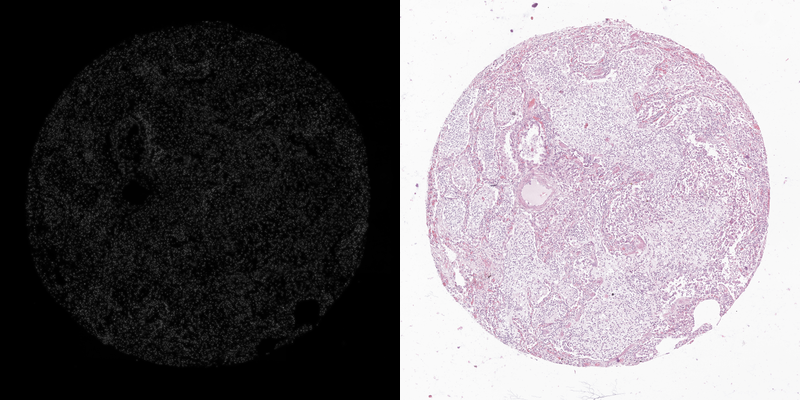

In [11]:
img1 = Image.open(output_dir + 'my_reg_project-modality_fluo_to_modality_brightfield_registered.ome.tiff')
img2 = Image.open(output_dir + 'my_reg_project-modality_brightfield_registered.ome.tiff')
img1 = img1.resize((400,400), Image.LANCZOS)
img2 = img2.resize((400,400), Image.LANCZOS)
img1 = img1.convert("RGB")
img2 = img2.convert("RGB")
new_img = Image.new("RGB", (800, 400))
new_img.paste(img1, (0, 0))
new_img.paste(img2, (400, 0))
display(new_img)

In [12]:
def parse_points_from_geojson(geojson_path):
    with open(geojson_path, 'r') as f:
        data = json.load(f)
    coords = data[0]['geometry']['coordinates']
    coords = np.array(coords)
    return coords

# Find the first .geojson file in the current directory
geojson_file = next((f for f in os.listdir("./" + output_dir) if f.endswith('.geojson')), None)
points = parse_points_from_geojson(output_dir + geojson_file)
print(Xenium_landmarks[:5])
print(points[:5])

# resize back the registered coordinates
points[:, 0] = points[:, 0] * (original_size[0] / query_img_size[0])
points[:, 1] = points[:, 1] * (original_size[1] / query_img_size[1])

# compare registered and unregistered coordinates
print(points[:5])
print(he_landmarks[:5])

[[4909.9256718  5010.98892279]
 [4330.619399   5322.77626833]
 [3968.26511795 5464.59804195]
 [3528.1100681  5524.93576076]
 [2766.12928672 5485.72350744]]
[[4944.8609676  4906.0776558 ]
 [4376.60835095 5192.03535752]
 [4021.16986039 5322.11621392]
 [3589.41919318 5377.4823266 ]
 [2841.99254069 5341.58727354]]
[[7414.96116819 7860.59370632]
 [6562.85003428 8318.75957082]
 [6029.85980007 8527.17713631]
 [5382.43726329 8615.88558068]
 [4261.64951201 8558.37396999]]
[[7415.22573193 7857.42793365]
 [6560.0275     8314.1       ]
 [6027.42938815 8526.25241387]
 [5377.05615153 8613.05751115]
 [4256.54914179 8555.53992469]]


In [13]:
# Remove everything under output_dir except .csv and .tiff files
for f in os.listdir(output_dir):
    if not (f.endswith('.csv') or f.endswith('.tiff')):
        path = os.path.join(output_dir, f)
        if os.path.isdir(path):
            shutil.rmtree(path)
        else:
            os.remove(path)

reg_graph = WsiReg2D("my_reg_project", output_dir= output_dir)

reg_graph.add_modality(
    "modality_fluo",
    output_dir + "input.tiff",
    image_res=1,
    preprocessing={
        "image_type": "BF",
        "as_uint8": True,
        "invert_intensity": True,
    },
)
reg_graph.add_modality(
    "modality_brightfield",
    output_dir + "output.tiff",
    image_res=1,
    preprocessing={
        "image_type": "FL", 
        "as_uint8": True,
        "invert_intensity": False,
    }
)
reg_graph.add_shape_set("modality_fluo", "Xenium_landmarks", {"array": Xenium_landmarks, "shape_type": "Point", "shape_name" : "Xenium_landmarks"}, 1)
reg_graph.add_reg_path(
    "modality_fluo",
    "modality_brightfield",
    thru_modality=None,
    reg_params=["rigid", "nl"],
)
reg_graph.register_images()
reg_graph.save_transformations()
reg_graph.transform_images(file_writer="ome.tiff")
reg_graph.transform_shapes()

def parse_points_from_geojson(geojson_path):
    with open(geojson_path, 'r') as f:
        data = json.load(f)
    coords = data[0]['geometry']['coordinates']
    coords = np.array(coords)
    return coords

# Find the first .geojson file in the current directory
geojson_file = next((f for f in os.listdir("./" + output_dir) if f.endswith('.geojson')), None)
nl_points = parse_points_from_geojson(output_dir + geojson_file)
print(Xenium_landmarks[:5])
print(nl_points[:5])

# resize back the registered coordinates
nl_points[:, 0] = nl_points[:, 0] * (original_size[0] / query_img_size[0])
nl_points[:, 1] = nl_points[:, 1] * (original_size[1] / query_img_size[1])


Writing preprocessed image for modality_fluo
Finished writing preprocessed image for modality_fluo
cannot perform maximum intensity project on single channel image
Writing preprocessed image for modality_brightfield
Finished writing preprocessed image for modality_brightfield
using default compression
saving to results/lungTMA6/my_reg_project-modality_fluo_to_modality_brightfield_registered.ome.tiff
transforming : 0
transformed : 0
saving
 writing channel 0 - shape: (5958, 6366)
pyramid index 1 : channel 0 shape: (2979, 3183)
pyramid index 2 : channel 0 shape: (1489, 1591)
pyramid index 3 : channel 0 shape: (744, 795)
preparing transforms for non-registered modality : modality_brightfield 
using default compression
saving to results/lungTMA6/my_reg_project-modality_brightfield_registered.ome.tiff
transforming : 0
transforming : 1
transforming : 2
RGB shape: (5958, 6366, 3)
transform at index 0 is non-linear and the inverse has not been computed
inverting displacement field(s)...
this c

[3.17680824 5.44777936 2.60038722 6.07900823 5.83485983]
[1.31468288 2.86275797 3.9341636  5.04701143 4.6674842 ]


The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


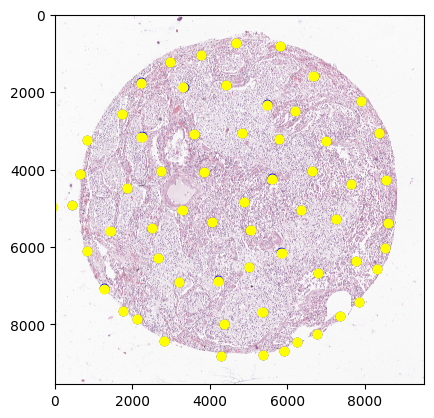

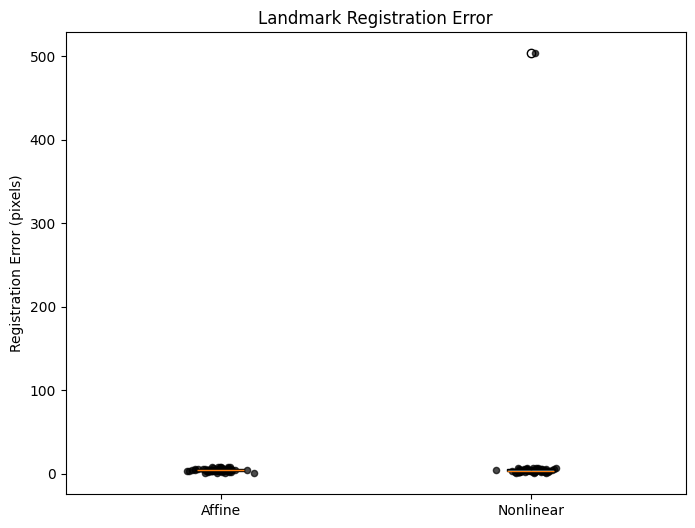

In [22]:
# visualize landmarks
fig,ax = plt.subplots()
img = ref_img
ax.scatter(he_landmarks[:,1], he_landmarks[:,0], alpha=1, c="blue")
ax.scatter(points[:,1], points[:,0], alpha=1, c="yellow")
ax.scatter(nl_points[:,1], nl_points[:,0], alpha=1, c="yellow")
ax.imshow(img)

# get distance between landmark and transformation
diff_affine = np.sqrt(np.power(np.array(points[:,0])-he_landmarks[:,0],2) + np.power(np.array(points[:,1])-he_landmarks[:,1],2))
print(diff_affine[:5])
diff_nl = np.sqrt(np.power(np.array(nl_points[:,0])-he_landmarks[:,0],2) + np.power(np.array(nl_points[:,1])-he_landmarks[:,1],2))
print(diff_nl[:5])

# visualize boxplots with points overlaid
fig2, ax2 = plt.subplots(figsize=(8, 6))
data = [diff_affine, diff_nl]
ax2.boxplot(data, labels=['Affine', 'Nonlinear'], patch_artist=True)
# Overlay the points (jittered for visibility)
for i, diff in enumerate(data, start=1):
    ax2.scatter(np.random.normal(i, 0.04, size=len(diff)), diff, alpha=0.7, color='black', s=20)
ax2.set_ylabel('Registration Error (pixels)')
ax2.set_title('Landmark Registration Error')
plt.show()

# save to data
df = pd.DataFrame({
    'x_landmark': he_landmarks[:,0],
    'y_landmark': he_landmarks[:,1],
    'x_wsireg_affine': points[:,0],
    'y_wsireg_affine': points[:,1],
    'x_wsireg_nl': nl_points[:,0],
    'y_wsireg_nl': nl_points[:,1],
    'diff_affine': diff_affine,
    'diff_nl': diff_nl
})
df.to_csv(output_dir + "all_landmarks.csv")

In [21]:
diff_affine.size

60